# Can we predict frequency of cannabis usage based on people's demographics, level of education, self-reported impulsivity levels, and gender?

In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 
import seaborn as sns

from ucimlrepo import fetch_ucirepo 
  
# Fetching the dataset

drug_consumption = fetch_ucirepo(id=373) 

# Converting the dataset to a pandas dataframe

drugs_df = pd.concat([drug_consumption.data.features, drug_consumption.data.targets], axis=1)

drugs_df.info() # Printing variable types
drugs_df.head() # Printing the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [ ]:
# Fixing typo in "impulsive" variable

drugs_df = drugs_df.rename(columns = {'impuslive': 'impulsive'})

# Only keeping necessary columns to predict cannabis usage

cannabis_df = drugs_df[['age', 'gender', 'education', 'country', 'ethnicity', 'impulsive', 'cannabis', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'ss']]

cannabis_df = cannabis_df.dropna() # Dropping any NA values

cannabis_df.head() # Printing the first five rows of the new dataset

,age,gender,education,country,ethnicity,impulsive,cannabis,nscore,escore,oscore,ascore,cscore,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,-0.21712,CL0,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.71126,CL4,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-1.37983,CL3,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-1.37983,CL2,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,-0.21712,CL3,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21575


In [40]:
cannabis_df[["cannabis"]] = OrdinalEncoder().fit_transform(cannabis_df[["cannabis"]]) # Ordinally encoding our target variable

print(cannabis_df['cannabis'].value_counts()) # Checking the statistics of each cannabis usage frequency category


cannabis
6.0    463
0.0    413
2.0    266
3.0    211
1.0    207
5.0    185
4.0    140
Name: count, dtype: int64


In [41]:
cannabis_df['education'].unique()

array([-0.05921,  1.98437,  1.16365, -1.22751, -1.7379 ,  0.45468,
       -0.61113, -2.43591, -1.43719])

In [42]:
cannabis_df['country'] = cannabis_df['country'].replace({
    0.96082:'UK', 
    0.24923:'Canada', 
    -0.57009:'USA',
    -0.28519:'Other', 
    -0.09765:'Australia',
    0.21128:'Republic of Ireland', 
    -0.46841:'New Zealand'})

cannabis_df['education'] = cannabis_df['education'].replace({
    -2.43591:"Left school before 16 years",
    -1.73790:"Left school at 16 years",
    -1.43719:"Left school at 17 years",
    -1.22751:"Left school at 18 years",
    -0.61113:"Some college or university, no certificate or degree",
    -0.05921:"Professional certificate/ diploma",
    0.45468:"University degree",
    1.16365:"Masters degree",
    1.98437:"Doctorate degree"
})

cannabis_df['age'] = cannabis_df['age'].replace({
    -0.95197: "18-24",
    -0.07854: "25-34",
    0.49788: "35-44",
    1.09449: "45-54",
    1.82213: "55-64",
    2.59171: "65+"
})
cannabis_df['gender'] = cannabis_df['gender'].replace({
    0.48246: "Female",
    -0.48246: "Male"
})

cannabis_df['ethnicity'] = cannabis_df['ethnicity'].replace({
    -0.50212: "Asian",
    -1.10702: "Black",
    1.90725: "Mixed-Black/Asian",
    0.12600: "Mixed-White/Asian",
    -0.22166: "Mixed-White/Black",
    0.11440: "Other", 
    -0.31685: "White"
})

In [43]:
# Splitting the data
cat_vars = ['country', 'education', 'age', 'gender', 'ethnicity']

for var in cat_vars:
        dummies = pd.get_dummies(cannabis_df[var], prefix=var) 
        cannabis_df = pd.concat([cannabis_df, dummies], axis=1)

        
cannabis_df= cannabis_df.drop(columns=cat_vars)


X = cannabis_df.drop(columns = 'cannabis') # Defining our feature variables
y = cannabis_df.cannabis # Defining our target variable

if isinstance(y, pd.Series):
    y.loc[y <= 2] = 0
    y.loc[(y > 2) & (y <= 6)] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, stratify= y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state = 30)

/tmp/ipykernel_4902/3140184229.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[y <= 2] = 0
/tmp/ipykernel_4902/3140184229.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[(y > 2) & (y <= 6)] = 1


In [44]:
# Variables we think will be important

vars = ['impulsive', 'ss', 'nscore','cannabis']

# Showing statistics by group, 0 for low/never used and 1 for moderate/heavy usage

print(cannabis_df[vars].groupby('cannabis').describe())

         impulsive                                                          \
             count      mean       std      min      25%      50%      75%   
cannabis                                                                     
0.0          886.0 -0.289980  0.908379 -2.55524 -0.71126 -0.21712  0.19268   
1.0          999.0  0.270795  0.916504 -2.55524 -0.21712  0.19268  0.88113   

                      ss            ...                   nscore            \
              max  count      mean  ...      75%      max  count      mean   
cannabis                            ...                                      
0.0       2.90161  886.0 -0.458533  ...  0.07987  1.92173  886.0 -0.115260   
1.0       2.90161  999.0  0.400456  ...  1.22470  1.92173  999.0  0.102311   

                                                                 
               std      min      25%      50%      75%      max  
cannabis                                                         
0.0       0.945131 -

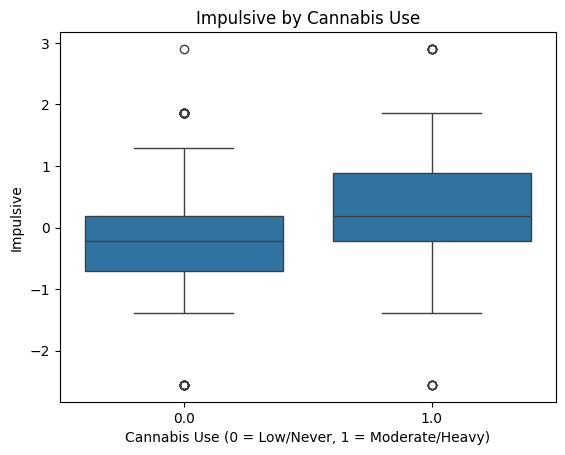

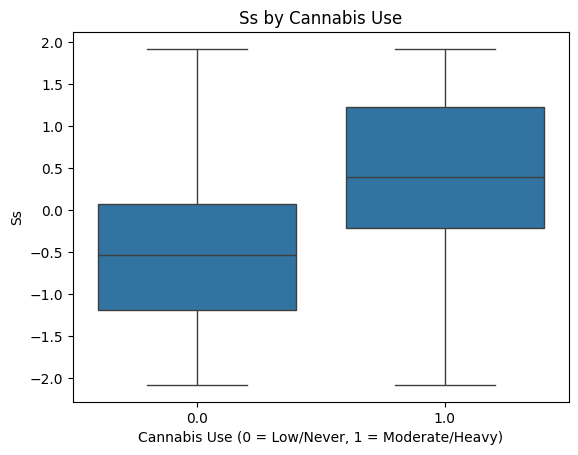

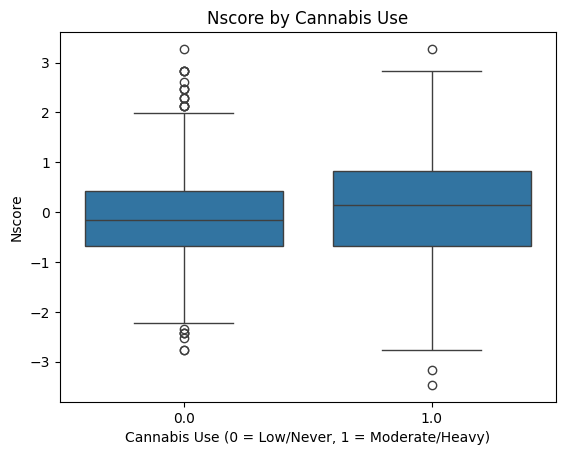

In [45]:
# Variables we think will be important

features = ['impulsive', 'ss', 'nscore']

# Plotting boxplots

for var in features:
    sns.boxplot(x='cannabis', y=var, data=cannabis_df)
    plt.title(f'{var.capitalize()} by Cannabis Use')
    plt.xlabel('Cannabis Use (0 = Low/Never, 1 = Moderate/Heavy)')
    plt.ylabel(var.capitalize())
    plt.show()


In [46]:
# Starting the cross validation process with 10 splits and 5 repeats

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state=42)

In [47]:
# Defining our scoring metrics

scoring = {
    'roc_auc': 'roc_auc_ovr',             
    'recall': 'recall_macro',               
    'balanced_accuracy': 'balanced_accuracy'  
}



In [48]:
# Using max_depth as our hyperparameter

param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    # "min_samples_leaf":[12,3,4,5,6,7,8,9,10],
    # "min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    # "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90], 
    # 'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    # 'ccp_alpha':[.001,.01,.1]
        }

In [49]:
cl = DecisionTreeClassifier(random_state=1000) # Defining the classifier model

# Searching for the best classifier based on balanced_accuracy

search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'balanced_accuracy') 

model = search.fit(X_train, y_train) # Fitting the model based on the training data

In [50]:
# Finding the best max_depth

best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=5, random_state=1000)


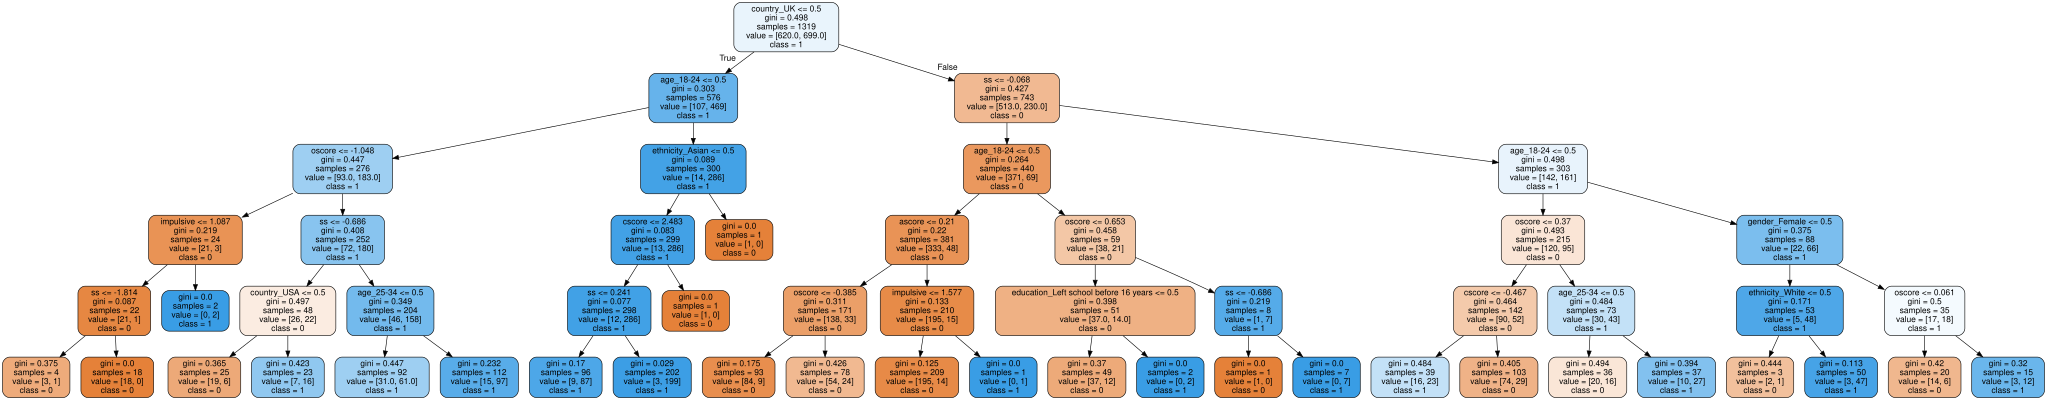

In [51]:
# Printing the decision tree

dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns,
               filled=True, 
                rounded=True, 
                class_names = ['0', '1'])
               
graph=graphviz.Source(dot_data)
graph

In [52]:
print(model.cv_results_)

{'mean_fit_time': array([0.00569611, 0.0062676 , 0.00665277, 0.007357  , 0.00676373,
       0.00884523, 0.00810966, 0.00892627, 0.01020239, 0.01040526,
       0.01013082, 0.01246917, 0.01025366, 0.01217676, 0.01064044,
       0.01051967, 0.01533582, 0.01695635, 0.01156558, 0.01106619]), 'std_fit_time': array([0.00305167, 0.00316645, 0.00227143, 0.00324033, 0.00089683,
       0.00353909, 0.00091741, 0.00144058, 0.00253652, 0.00186188,
       0.0012803 , 0.00432706, 0.00071103, 0.00463767, 0.00186086,
       0.0022235 , 0.00777376, 0.00632772, 0.00361648, 0.00294045]), 'mean_score_time': array([0.01296562, 0.0133882 , 0.01335106, 0.01165571, 0.01012707,
       0.01122254, 0.00987988, 0.00998171, 0.01029272, 0.01010493,
       0.01004344, 0.01209885, 0.0098912 , 0.01183683, 0.0096504 ,
       0.00968014, 0.01372252, 0.01768555, 0.01059451, 0.0108157 ]), 'std_score_time': array([0.00474557, 0.0073812 , 0.00526503, 0.00503984, 0.00049029,
       0.00279446, 0.0006064 , 0.00105477, 0.0022014

In [53]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']


for key in param:
    params = str("param_" + key)

depth= np.unique(model.cv_results_[params])

final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

final_model

,depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
0,1,0.749186,0.749186,0.749186,0.032189,0.032189,0.032189
1,2,0.833771,0.749733,0.749733,0.032177,0.034475,0.034475
2,3,0.847282,0.778597,0.778597,0.028025,0.027310,0.027310
3,4,0.852028,0.773244,0.773244,0.030689,0.034833,0.034833
4,5,0.842583,0.781684,0.781684,0.036874,0.034805,0.034805
5,6,0.823360,0.766142,0.766142,0.037657,0.039384,0.039384
6,7,0.789561,0.758075,0.758075,0.042975,0.039954,0.039954
7,8,0.768589,0.750869,0.750869,0.045164,0.039230,0.039230
8,9,0.753779,0.747681,0.747681,0.046016,0.037633,0.037633
9,10,0.741093,0.739825,0.739825,0.043673,0.042095,0.042095


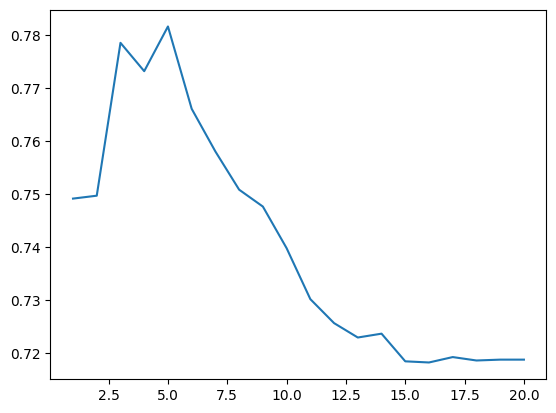

In [54]:
# Finding what depth has the highest balanced accuracy

print(plt.plot(final_model.depth,final_model.bal_acc))

In [55]:
varimp = pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                                                    importance
country_UK                                            0.485217
ss                                                    0.179308
age_18-24                                             0.121794
oscore                                                0.097038
cscore                                                0.021166
age_25-34                                             0.020944
gender_Female                                         0.018958
impulsive                                             0.014895
country_USA                                           0.014603
ascore                                                0.008176
education_Left school before 16 years                 0.006433
ethnicity_White                                       0.006116
ethnicity_Asian                                       0.005354
nscore                                                0.000000
escore                                                0

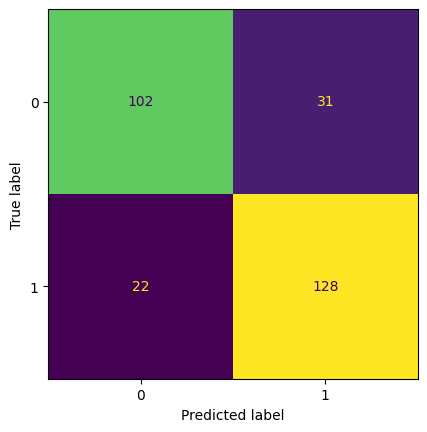

In [56]:
print(ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune, labels=[0, 1],colorbar=False))